# IRP Stage 2 — Data Sampling & Feature Engineering
**MLOps Group Project | Section 1, Group 5**\
*Maria-Irina Popa, Enzo Jerez, Roberto Cummings, Jia Yi Rachel Lee, Thomas Christian Matenco*

---

This notebook builds on the Stage 1 baseline with two concrete upgrades:

1. **Sampling toggle** — `SAMPLE_FRAC` at the top of the notebook - set to `0.1` for fast iteration (see speedup verification cell for measured ratio), `1.0` for full training. All pipeline logic stays identical either way.
2. **Feature engineering** — 11 new features are derived from existing columns, each with a clear business rationale for inventory risk prediction. Three bugs from the initial version are also fixed here.

### Notebook Structure
| Part | Content |
|---|---|
| **Part 1** | Data Loading & Setup |
| **Part 2** | Feature Engineering |
| **Part 3** | Logistic Regression Baseline |
| **Part 4** | Pipeline Export (`src/pipeline.py`) |


---
## Part 1 — Data Loading & Setup

### 1.1 Imports

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
print("Libraries loaded ✓")

Libraries loaded ✓


### 1.2 Load the data

In [2]:
DATA_PATH = "../retail_store_inventory.csv"

df_orig = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df_orig = df_orig.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

print(f"Shape: {df_orig.shape}")
print(f"Date range: {df_orig['Date'].min().date()} → {df_orig['Date'].max().date()}")
print(f"Missing values: {df_orig.isnull().sum().sum()}")
df_orig.head()

Shape: (73100, 15)
Date range: 2022-01-01 → 2024-01-01
Missing values: 0


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


In [3]:
# Create new df to store cleaned data
df = df_orig.copy()

In [4]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

### 1.3 Config — Single Source of Truth

All thresholds, split dates, and sampling parameters are defined here.
Changing a value in this cell propagates to the entire notebook.

| Parameter | Value | Purpose |
|---|---|---|
| `THETA_LOW` | 1.2 | Stockout: Inventory < Demand × θ_low |
| `THETA_HIGH` | 4.5 | Overstock: Inventory > Demand × θ_high |
| `SALES_VEL` | 0.8 | Overstock also requires low sales velocity |
| `CUTOFF_VAL` | 2023-07-01 | Train / Val split date |
| `CUTOFF_TEST` | 2023-11-01 | Val / Test split date |

> When both Stockout and Overstock conditions are met, **Stockout Risk takes precedence** (higher cost implication).

In [6]:
# Labelling thresholds
THETA_LOW   = 1.2    # Stockout:  Inventory < Demand x THETA_LOW
THETA_HIGH  = 4.5    # Overstock: Inventory > Demand x THETA_HIGH
SALES_VEL   = 0.8    # Overstock also requires Units Sold < Demand x SALES_VEL

# Temporal split dates
CUTOFF_VAL  = "2023-07-01"
CUTOFF_TEST = "2023-11-01"

# Reproducibility
RANDOM_STATE = 42

print(f"THETA_LOW    : {THETA_LOW}")
print(f"THETA_HIGH   : {THETA_HIGH}")
print(f"SALES_VEL    : {SALES_VEL}")
print(f"CUTOFF_VAL   : {CUTOFF_VAL}")
print(f"CUTOFF_TEST  : {CUTOFF_TEST}")

THETA_LOW    : 1.2
THETA_HIGH   : 4.5
SALES_VEL    : 0.8
CUTOFF_VAL   : 2023-07-01
CUTOFF_TEST  : 2023-11-01


In [7]:
df = df_orig.copy()
df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
print(f"Dataset: {len(df):,} rows")

Dataset: 73,100 rows


---
## Part 2 — Feature Engineering


*For easy reference:*
| Label | Condition |
|---|---|
| **Stockout Risk** | `Inventory Level < Demand Forecast × θ_low` |
| **Overstock Risk** | `Inventory Level > Demand Forecast × θ_high` AND low sales velocity |
| **Safe Zone** | Neither condition met |

> When both conditions are met, **Stockout Risk takes precedence** (higher cost implication).  
> Thresholds `θ_low` and `θ_high` are treated as tunable parameters.


### 2.1 Fix Negative Demand Forecast Values

In [8]:
# Fix datatypes for downstream model compatibility
cat_cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
df[cat_cols] = df[cat_cols].astype('category')
df['Holiday/Promotion'] = df['Holiday/Promotion'].astype(bool)

print(f"Of which strictly negative         : {(df['Demand Forecast'] < 0).sum()}")
print()
print(df['Demand Forecast'].describe())

Of which strictly negative         : 673

count    73100.000000
mean       141.494720
std        109.254076
min         -9.990000
25%         53.670000
50%        113.015000
75%        208.052500
max        518.550000
Name: Demand Forecast, dtype: float64


In [9]:
df["Demand_Forecast_Clean"] = df["Demand Forecast"].clip(lower=1)
print(f"After clipping - min value : {df['Demand_Forecast_Clean'].min():.2f}")
print(f"Rows affected              : {(df['Demand Forecast'] < 1).sum()}")

After clipping - min value : 1.00
Rows affected              : 829


673 rows contain negative Demand Forecast values, which are physically impossible.
Dividing by a negative demand value flips the sign of ratio-based features, causing
stockout situations to appear as overstock to the model.

These are clipped to a minimum of 1 and stored in `Demand_Forecast_Clean`, leaving the original column untouched for reference.

In [10]:
# Temporal split dates (same as Stage 1)
CUTOFF_VAL  = "2023-07-01"
CUTOFF_TEST = "2023-11-01"

print(f"CUTOFF_VAL   : {CUTOFF_VAL}")
print(f"CUTOFF_TEST  : {CUTOFF_TEST}")

CUTOFF_VAL   : 2023-07-01
CUTOFF_TEST  : 2023-11-01


### 2.2 Inventory Reconstruction

The raw `Inventory Level` in this synthetic dataset is randomly generated without inventory management logic. A physically meaningful running balance is reconstructed:

`Inventory(t) = max(Inventory(t-1) − Units Sold(t-1) + Units Ordered(t-1), 0)`

A simple cumulative sum is not used because the floor-at-zero creates path dependency — once inventory hits 0, subsequent values restart from 0 rather than going negative.

> **Note:** Due to the synthetic nature of the data, the reconstructed series produces zero-inventory periods for ~24.5% of rows. Labels are derived from raw `Inventory Level` (not reconstructed) to avoid threshold distortion from these artefact zeros.

In [11]:
def reconstruct_inventory(group):
    """Reconstruct inventory as a running balance:
    Inventory(t) = max(Inventory(t-1) - Units Sold(t-1) + Units Ordered(t-1), 0)
    """
    group = group.sort_values("Date").copy()
    sold    = group["Units Sold"].values
    ordered = group["Units Ordered"].values
    n   = len(group)
    inv = np.empty(n, dtype=np.float64)
    inv[0] = group["Inventory Level"].iloc[0]
    for i in range(1, n):
        inv[i] = max(inv[i-1] - sold[i-1] + ordered[i-1], 0.0)
    group["Inventory_Reconstructed"] = inv
    return group

In [12]:
reconstructed = []
for (store, product), group in df.groupby(["Store ID", "Product ID"], sort=False):
    reconstructed.append(reconstruct_inventory(group))

df = pd.concat(reconstructed).sort_values(
    ["Store ID", "Product ID", "Date"]).reset_index(drop=True)

print("Inventory reconstruction complete.")
print(f"  Original mean      : {df['Inventory Level'].mean():.1f}")
print(f"  Reconstructed mean : {df['Inventory_Reconstructed'].mean():.1f}")
print(f"  Reconstructed min  : {df['Inventory_Reconstructed'].min():.1f}")
print(f"  Zero-inventory rows: {(df['Inventory_Reconstructed'] == 0).sum():,}  "
      f"({(df['Inventory_Reconstructed']==0).mean()*100:.1f}%)")

Inventory reconstruction complete.
  Original mean      : 274.5
  Reconstructed mean : 204.0
  Reconstructed min  : 0.0
  Zero-inventory rows: 17,824  (24.4%)


### 2.3 Engineer All 11 Features

Features are grouped into four types, each capturing a different dimension of inventory risk:

| Type | Feature | Business Rationale |
|---|---|---|
| Ratio | `Coverage_Ratio` | Days of demand covered by current stock |
| Ratio | `Sales_Velocity` | How fast is stock turning over? |
| Ratio | `Forecast_Error` | How far off was the demand forecast? |
| Ratio | `Order_to_Inventory` | Replenishment pressure signal |
| Depletion | `Inventory_Change` | Day-over-day absolute stock change |
| Depletion | `Inventory_Change_Pct` | Relative depletion rate |
| Depletion | `Days_of_Stock` | Days until stockout at current sales pace |
| Depletion | `Inventory_vs_Rolling7` | Deviation from 7-day rolling average |
| Time-series | `Inventory_Lag1` | Yesterday's inventory level |
| Time-series | `Units_Sold_Lag1` | Yesterday's units sold |
| Time-series | `Rolling7_Inventory` | 7-day rolling mean inventory |

> All lag and rolling calculations use `shift(1)` — only past information is used, no lookahead.

In [13]:
# Time-series features
df["Inventory_Lag1"]     = df.groupby(["Store ID", "Product ID"])["Inventory_Reconstructed"].shift(1)
df["Units_Sold_Lag1"]    = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
df["Rolling7_Inventory"] = (
    df.groupby(["Store ID", "Product ID"])["Inventory_Reconstructed"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# Depletion features
df["Inventory_Change"]     = df["Inventory_Reconstructed"] - df["Inventory_Lag1"]
df["Inventory_Change_Pct"] = (
    df["Inventory_Change"] / df["Inventory_Lag1"].replace(0, np.nan)
).fillna(0)
df["Days_of_Stock"] = (
    df["Inventory_Reconstructed"] / df["Units Sold"].replace(0, np.nan)
).fillna(df["Inventory_Reconstructed"] / df["Demand_Forecast_Clean"])
df["Days_of_Stock"] = df["Days_of_Stock"].replace([np.inf, -np.inf], np.nan)
df["Inventory_vs_Rolling7"] = df["Inventory_Reconstructed"] - df["Rolling7_Inventory"]

# Ratio & context features
df["Sales_Velocity"] = (
    df["Units Sold"] / df["Inventory_Reconstructed"].replace(0, np.nan)
).fillna(0).replace([np.inf, -np.inf], np.nan)
df["Coverage_Ratio"]     = df["Inventory_Reconstructed"] / df["Demand_Forecast_Clean"]
df["Forecast_Error"]     = df["Units Sold"] - df["Demand Forecast"]
df["Order_to_Inventory"] = (
    df["Units Ordered"] / df["Inventory_Reconstructed"].replace(0, np.nan)
).fillna(0).replace([np.inf, -np.inf], 0)

print("All 11 features engineered ✓")

All 11 features engineered ✓


In [14]:
print(f"  NaNs in Inventory_Lag1     : {df['Inventory_Lag1'].isna().sum()}")
print(f"  NaNs in Rolling7_Inventory : {df['Rolling7_Inventory'].isna().sum()}")

n_before = len(df)
df = df.dropna(subset=["Inventory_Lag1", "Rolling7_Inventory"]).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f"\nRows dropped   : {n_dropped}  ({n_dropped/n_before*100:.1f}% - first 7 days per series)")
print(f"Rows remaining : {len(df):,}")

  NaNs in Inventory_Lag1     : 100
  NaNs in Rolling7_Inventory : 700

Rows dropped   : 700  (1.0% - first 7 days per series)
Rows remaining : 72,400


In [15]:
df[["Store ID", "Product ID", "Date",
    "Inventory_Reconstructed", "Coverage_Ratio", "Days_of_Stock",
    "Inventory_Lag1", "Rolling7_Inventory"]].head(10)

,Store ID,Product ID,Date,Inventory_Reconstructed,Coverage_Ratio,Days_of_Stock,Inventory_Lag1,Rolling7_Inventory
0,S001,P0001,2022-01-08,508.0,508.000000,254.000000,509.0,334.142857
1,S001,P0001,2022-01-09,625.0,1.774358,1.785714,508.0,373.714286
2,S001,P0001,2022-01-10,453.0,11.468354,12.583333,625.0,440.285714
3,S001,P0001,2022-01-11,549.0,34.078212,34.312500,453.0,479.000000
4,S001,P0001,2022-01-12,726.0,7.236842,6.980769,549.0,505.142857
5,S001,P0001,2022-01-13,811.0,10.312818,10.137500,726.0,537.285714
6,S001,P0001,2022-01-14,921.0,4.766341,5.203390,811.0,597.285714
7,S001,P0001,2022-01-15,788.0,4.633659,4.477273,921.0,656.142857
8,S001,P0001,2022-01-16,706.0,6.157872,7.278351,788.0,696.142857
9,S001,P0001,2022-01-17,798.0,10.843865,11.565217,706.0,707.714286


### 2.4 Analysis of Engineered Features

Engineered features are visualised to confirm they carry the expected signal for inventory risk. Temporary labels are applied here **for visualisation only** — official labels are computed in Section 2.5.

In [16]:
# Temporary labels for EDA only
df_viz = df.copy()
df_viz["Risk_Label_Current"] = "Safe Zone"
df_viz.loc[df_viz["Inventory_Reconstructed"] < df_viz["Demand_Forecast_Clean"] * THETA_LOW,
           "Risk_Label_Current"] = "Stockout Risk"
df_viz.loc[(df_viz["Inventory_Reconstructed"] > df_viz["Demand_Forecast_Clean"] * THETA_HIGH) &
           (df_viz["Units Sold"] < df_viz["Demand_Forecast_Clean"] * SALES_VEL),
           "Risk_Label_Current"] = "Overstock Risk"
df_viz["Risk_Label"] = df_viz.groupby(["Store ID", "Product ID"])["Risk_Label_Current"].shift(-1)
df_viz = df_viz.dropna(subset=["Risk_Label"]).reset_index(drop=True)

COLORS = {"Safe Zone": "#4C72B0", "Stockout Risk": "#C44E52", "Overstock Risk": "#DD8452"}
LABELS = ["Stockout Risk", "Overstock Risk", "Safe Zone"]
print("Temporary labels applied for visualisation.")

Temporary labels applied for visualisation.


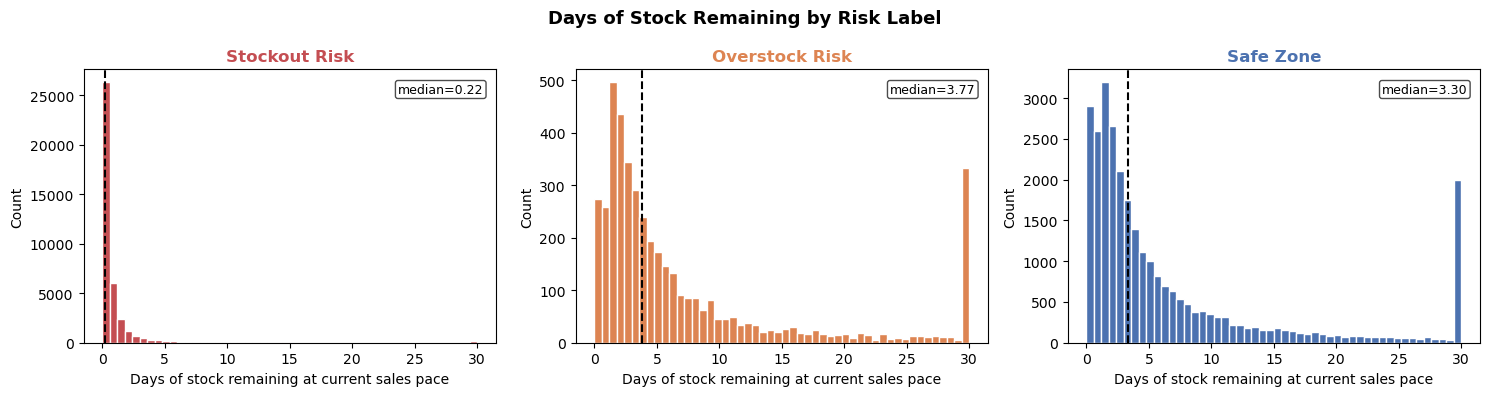

  Stockout Risk       median Days_of_Stock = 0.22
  Overstock Risk      median Days_of_Stock = 3.77
  Safe Zone           median Days_of_Stock = 3.30


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("Days of Stock Remaining by Risk Label", fontsize=13, fontweight="bold")

for ax, label in zip(axes, LABELS):
    sub = df_viz[df_viz["Risk_Label"] == label]
    ax.hist(sub["Days_of_Stock"].clip(0, 30), bins=50,
            color=COLORS[label], edgecolor='white')
    ax.set_title(label, color=COLORS[label], fontweight='bold')
    ax.set_xlabel('Days of stock remaining at current sales pace')
    ax.set_ylabel('Count')
    median_val = sub["Days_of_Stock"].median()
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    ax.text(0.97, 0.95, f'median={median_val:.2f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

for label in LABELS:
    sub = df_viz[df_viz["Risk_Label"] == label]
    print(f"  {label:18s}  median Days_of_Stock = {sub['Days_of_Stock'].median():.2f}")

**Key Insight — Days of Stock as a Leading Risk Indicator:**

| Risk Class | Median Days of Stock | Interpretation |
|---|---|---|
| Stockout Risk | ~0.22 | Nearly zero stock — depletion already underway |
| Overstock Risk | ~3.77 | Large buffer, slow sales — accumulation in progress |
| Safe Zone | ~3.30 | Balanced: comfortably covers near-term demand |

The near-zero values for Stockout Risk confirm this feature directly captures the depletion dynamic driving next-day stockout events.

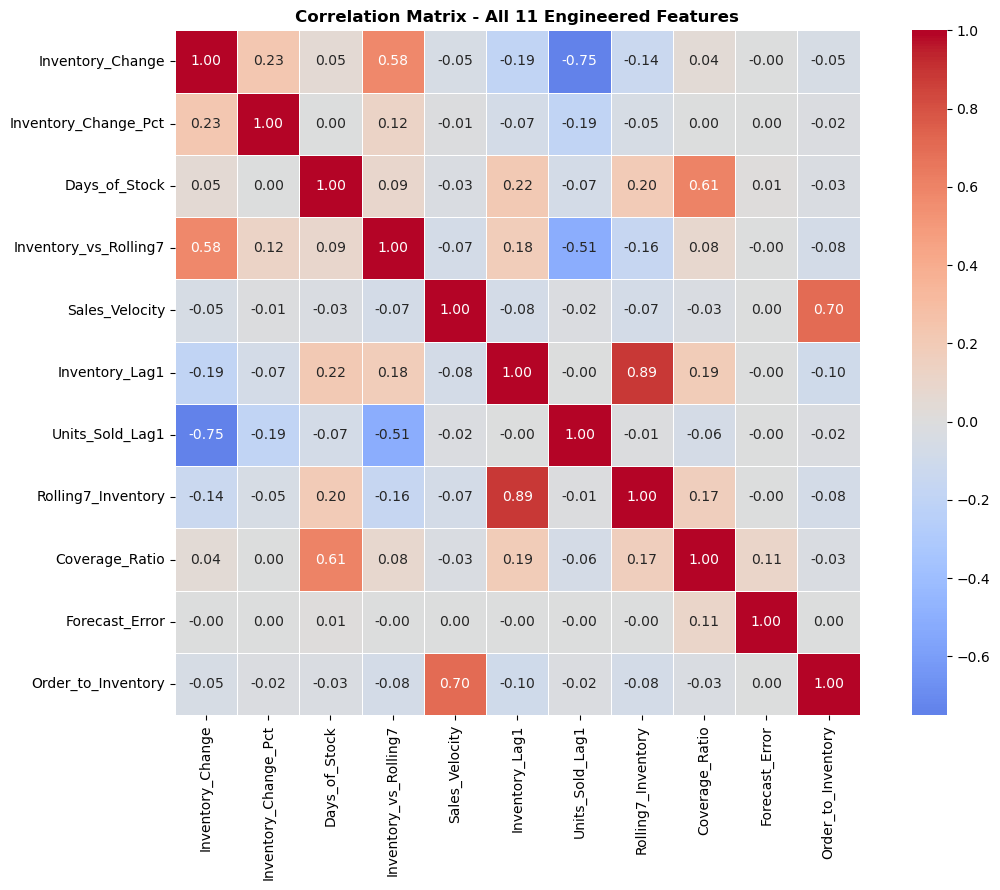

In [18]:
engineered_features = [
    "Inventory_Change", "Inventory_Change_Pct", "Days_of_Stock",
    "Inventory_vs_Rolling7", "Sales_Velocity",
    "Inventory_Lag1", "Units_Sold_Lag1", "Rolling7_Inventory",
    "Coverage_Ratio", "Forecast_Error", "Order_to_Inventory",
]

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_viz[engineered_features].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix - All 11 Engineered Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Low multicollinearity overall** — most features are near-independent.
- **Expected high correlations:** `Inventory_Lag1` / `Rolling7_Inventory` (0.89) and `Inventory_Change` / `Units_Sold_Lag1` (-0.75) are logically grounded — derived from the same series.
- **`Days_of_Stock` and `Sales_Velocity`** show near-zero correlations with all other features.

A formal VIF check is conducted in Part 3 (Section 3.4) on the training set only.

### 2.5 Labelling

Labels are derived from raw `Inventory Level` (not reconstructed), consistent with Stage 1.
Raw inventory is what store managers observe in their systems — the correct basis for operational thresholds.

A **t+1 shift** is applied: today's features predict **tomorrow's** risk label.

| Label | Condition |
|---|---|
| Stockout Risk | `Inventory Level < Demand_Forecast_Clean x THETA_LOW` |
| Overstock Risk | `Inventory Level > Demand_Forecast_Clean x THETA_HIGH` AND low sales |
| Safe Zone | Neither condition met |

In [19]:
df["Risk_Label_Current"] = "Safe Zone"
df.loc[df["Inventory Level"] < df["Demand_Forecast_Clean"] * THETA_LOW,
       "Risk_Label_Current"] = "Stockout Risk"
df.loc[(df["Inventory Level"] > df["Demand_Forecast_Clean"] * THETA_HIGH) &
       (df["Units Sold"] < df["Demand_Forecast_Clean"] * SALES_VEL),
       "Risk_Label_Current"] = "Overstock Risk"

df["Risk_Label"] = df.groupby(["Store ID", "Product ID"])["Risk_Label_Current"].shift(-1)
df = df.dropna(subset=["Risk_Label"]).reset_index(drop=True)

print(f"Labels applied  (theta_low={THETA_LOW}, theta_high={THETA_HIGH}, sales_vel={SALES_VEL})")
counts = df["Risk_Label"].value_counts()
for label, count in counts.items():
    print(f"  {label:<18} {count:>6,}  ({count/len(df)*100:.1f}%)")

minority = counts[["Stockout Risk", "Overstock Risk"]].mean()
print(f"\nClass imbalance: Safe Zone is {counts['Safe Zone']/minority:.0f}x larger than average minority class")

Labels applied  (theta_low=1.2, theta_high=4.5, sales_vel=0.8)
  Safe Zone          53,113  (73.5%)
  Stockout Risk      13,914  (19.2%)
  Overstock Risk      5,273  (7.3%)

Class imbalance: Safe Zone is 6x larger than average minority class


---
## Part 3 — Preprocessing for Modelling

### 3.1 Temporal Split

The dataset is split chronologically into three non-overlapping sets. No random shuffling — temporal order must be strictly preserved.

| Split | Date Range | Purpose |
|---|---|---|
| **Train** | Jan 2022 → Jun 2023 | Model fitting |
| **Val** | Jul 2023 → Oct 2023 | Hyperparameter tuning & model selection |
| **Test** | Nov 2023 → Jan 2024 | Final held-out evaluation |

NaN imputation uses **train-only medians** applied to all three splits.

In [20]:
train = df[df["Date"] <  pd.Timestamp(CUTOFF_VAL)].copy()
val   = df[(df["Date"] >= pd.Timestamp(CUTOFF_VAL)) & (df["Date"] < pd.Timestamp(CUTOFF_TEST))].copy()
test  = df[df["Date"] >= pd.Timestamp(CUTOFF_TEST)].copy()

# Impute NaN using TRAIN-ONLY medians
for col in ["Days_of_Stock", "Sales_Velocity"]:
    train_median = train[col].median()
    train[col] = train[col].fillna(train_median)
    val[col]   = val[col].fillna(train_median)
    test[col]  = test[col].fillna(train_median)

print(f"Train : {len(train):>6,}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Val   : {len(val):>6,}  ({val['Date'].min().date()} → {val['Date'].max().date()})")
print(f"Test  : {len(test):>6,}  ({test['Date'].min().date()} → {test['Date'].max().date()})")

# Assert no temporal leakage
assert train["Date"].max() < pd.Timestamp(CUTOFF_VAL)
assert val["Date"].min()   >= pd.Timestamp(CUTOFF_VAL)
assert val["Date"].max()   <  pd.Timestamp(CUTOFF_TEST)
assert test["Date"].min()  >= pd.Timestamp(CUTOFF_TEST)
print("\u2705 No temporal leakage confirmed")

Train : 53,900  (2022-01-08 → 2023-06-30)
Val   : 12,300  (2023-07-01 → 2023-10-31)
Test  :  6,100  (2023-11-01 → 2023-12-31)
✅ No temporal leakage confirmed


In [21]:
for name, split in [("Train", train), ("Val", val), ("Test", test)]:
    counts = split["Risk_Label"].value_counts()
    print(f"\n{name} class distribution:")
    for label, count in counts.items():
        print(f"  {label:<18} {count:>5,}  ({count/len(split)*100:.1f}%)")


Train class distribution:
  Safe Zone          39,570  (73.4%)
  Stockout Risk      10,381  (19.3%)
  Overstock Risk     3,949  (7.3%)

Val class distribution:
  Safe Zone          9,094  (73.9%)
  Stockout Risk      2,318  (18.8%)
  Overstock Risk       888  (7.2%)

Test class distribution:
  Safe Zone          4,449  (72.9%)
  Stockout Risk      1,215  (19.9%)
  Overstock Risk       436  (7.1%)


### 3.3 Define Feature Matrix & Target

In [22]:
target = "Risk_Label"

In [23]:
# Check all columns first
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Demand_Forecast_Clean',
       'Inventory_Reconstructed', 'Inventory_Lag1', 'Units_Sold_Lag1',
       'Rolling7_Inventory', 'Inventory_Change', 'Inventory_Change_Pct',
       'Days_of_Stock', 'Inventory_vs_Rolling7', 'Sales_Velocity',
       'Coverage_Ratio', 'Forecast_Error', 'Order_to_Inventory',
       'Risk_Label_Current', 'Risk_Label'],
      dtype='object')

In [24]:
# Drop columsn that obviously should not be part of the modelling
drop_cols = [
    "Risk_Label",           # target
    "Risk_Label_Current",   # leakage
    "Store ID",             # ID
    "Product ID",           # ID
    "Date",                 # not needed for now
    "Demand Forecast",      # used in label
    "Demand_Forecast_Clean" # used in label
]

In [25]:
X_train = train.drop(columns=drop_cols)
X_val   = val.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

y_train = train[target]
y_val   = val[target]
y_test  = test[target]

In [26]:
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing', 'Inventory_Reconstructed', 'Inventory_Lag1', 'Units_Sold_Lag1', 'Rolling7_Inventory', 'Inventory_Change', 'Inventory_Change_Pct', 'Days_of_Stock', 'Inventory_vs_Rolling7', 'Sales_Velocity', 'Coverage_Ratio', 'Forecast_Error', 'Order_to_Inventory']
Categorical: ['Category', 'Region', 'Weather Condition', 'Seasonality']


# 4. Logistic Regression

### 4.1 Multicollinearity check

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_num = X_train[numerical_features].copy()
X_num["const"] = 1

vif = pd.DataFrame({
    "feature": X_num.columns,
    "VIF": [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
})

print(vif.sort_values("VIF", ascending=False))

                    feature           VIF
9        Rolling7_Inventory           inf
7            Inventory_Lag1           inf
13    Inventory_vs_Rolling7           inf
10         Inventory_Change           inf
6   Inventory_Reconstructed  1.061807e+04
3                     Price  8.219366e+01
5        Competitor Pricing  8.095037e+01
18                    const  2.196765e+01
8           Units_Sold_Lag1  2.416618e+00
14           Sales_Velocity  2.022904e+00
17       Order_to_Inventory  2.022140e+00
12            Days_of_Stock  1.736642e+00
15           Coverage_Ratio  1.713396e+00
1                Units Sold  1.627996e+00
0           Inventory Level  1.534448e+00
11     Inventory_Change_Pct  1.059068e+00
2             Units Ordered  1.021041e+00
16           Forecast_Error  1.020417e+00
4                  Discount  1.000288e+00


In [28]:
# Update numerical features
numerical_features = [
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Price',
    'Discount',
    'Units_Sold_Lag1',
    'Inventory_Change_Pct',
    'Days_of_Stock',
    'Sales_Velocity',
    'Coverage_Ratio',
    'Forecast_Error',
    'Order_to_Inventory'
]

categorical_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']

In [29]:
# Run VIF check again
X_num = X_train[numerical_features].copy()

# Add constant (required for VIF)
X_num["const"] = 1

# Compute VIF
vif = pd.DataFrame({
    "feature": X_num.columns,
    "VIF": [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
})

# Sort for readability
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                 feature        VIF
12                 const  18.583894
8         Sales_Velocity   2.020825
11    Order_to_Inventory   2.000477
9         Coverage_Ratio   1.704857
7          Days_of_Stock   1.703888
1             Units Sold   1.625021
0        Inventory Level   1.534550
5        Units_Sold_Lag1   1.045935
6   Inventory_Change_Pct   1.038936
2          Units Ordered   1.021153
10        Forecast_Error   1.020221
3                  Price   1.000374
4               Discount   1.000263


### 4.2 Build the pipeline for Logistic Regression

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

logit_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

In [31]:
# Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

In [32]:
# Fit and train the model
logit_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Inventory Level',
                                                   'Units Sold',
                                                   'Units Ordered', 'Price',
                                                   'Discount',
                                                   'Units_Sold_Lag1',
                                                   'Inventory_Change_Pct',
                                                   'Days_of_Stock',
                                                   'Sales_Velocity',
                                                   'Coverage_Ratio',
                                                   'Forecast_Error',
                                                   'Order_to_Inventory']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Category', 'Region',
                                                   'Weather Condition',
                                                   'Seasonality'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [33]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Predictions
y_train_pred_logit = logit_pipeline.predict(X_train)
y_val_pred_logit   = logit_pipeline.predict(X_val)
y_test_pred_logit  = logit_pipeline.predict(X_test)

# Class labels + names
all_labels = [0, 1, 2]
class_names = ["Stockout Risk", "Safe Zone", "Overstock Risk"]

def evaluate(y_true, y_pred, name):
    print(f"\n{name} RESULTS")
    print("-" * 30)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("F1 (macro):", round(f1_score(y_true, y_pred, average="macro"), 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=all_labels,
        target_names=class_names,
        zero_division=0
    ))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    print(pd.DataFrame(cm, index=class_names, columns=class_names))

evaluate(y_train, y_train_pred_logit, "TRAIN")
evaluate(y_val, y_val_pred_logit, "VALIDATION")
evaluate(y_test, y_test_pred_logit, "TEST")


TRAIN RESULTS
------------------------------
Accuracy: 0.3291
F1 (macro): 0.2754

Classification Report:
                precision    recall  f1-score   support

 Stockout Risk       0.08      0.37      0.13      3949
     Safe Zone       0.73      0.32      0.45     39570
Overstock Risk       0.20      0.33      0.25     10381

      accuracy                           0.33     53900
     macro avg       0.34      0.34      0.28     53900
  weighted avg       0.58      0.33      0.39     53900

Confusion Matrix:
                Stockout Risk  Safe Zone  Overstock Risk
Stockout Risk            1477       1288            1184
Safe Zone               14212      12838           12520
Overstock Risk           3604       3351            3426

VALIDATION RESULTS
------------------------------
Accuracy: 0.3259
F1 (macro): 0.2681

Classification Report:
                precision    recall  f1-score   support

 Stockout Risk       0.07      0.37      0.12       888
     Safe Zone       0.74    

## 5. Random Forest

### 5.1 Pipeline

In [34]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Ensure correct dtypes
for col in categorical_features:
    X_train[col] = X_train[col].astype("object")
    X_val[col] = X_val[col].astype("object")
    X_test[col] = X_test[col].astype("object")

# Indices of categorical columns
cat_indices = [X_train.columns.get_loc(col) for col in categorical_features]

# SMOTENC
smote_nc = SMOTENC(
    categorical_features=cat_indices,
    random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Final pipeline
rf_pipeline = Pipeline(steps=[
    ('smote', smote_nc),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:
# Fit Random Forest pipeline
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote',
                 SMOTENC(categorical_features=[0, 1, 7, 10], random_state=42)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Inventory Level',
                                                   'Units Sold',
                                                   'Units Ordered', 'Price',
                                                   'Discount',
                                                   'Units_Sold_Lag1',
                                                   'Inventory_Change_Pct',
                                                   'Days_of_Stock',
                                                   'Sales_Velocity',
                                                   'Coverage_Ratio',
                                                   'Forecast_Error',
                                                   'Order_to_Inventory']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Region',
                                                   'Weather Condition',
                                                   'Seasonality'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [36]:
# Evaluate Random Forest Model
from sklearn.metrics import accuracy_score, classification_report

label_map = {
    0: "Stockout Risk",
    1: "Safe Zone",
    2: "Overstock Risk"
}

def evaluate(model, X, y, name, use_labels=True):
    preds = model.predict(X)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, preds))
    
    if use_labels:
        preds_named = [label_map[p] for p in preds]
        y_named = [label_map[t] for t in y]
        print(classification_report(y_named, preds_named))
    else:
        print(classification_report(y, preds))
    
    return preds

train_preds = evaluate(rf_pipeline, X_train, y_train, "TRAIN")
val_preds   = evaluate(rf_pipeline, X_val, y_val, "VALIDATION")
test_preds  = evaluate(rf_pipeline, X_test, y_test, "TEST")


TRAIN
Accuracy: 0.5219480519480519
                precision    recall  f1-score   support

Overstock Risk       0.26      0.16      0.20     10381
     Safe Zone       0.75      0.64      0.69     39570
 Stockout Risk       0.10      0.35      0.15      3949

      accuracy                           0.52     53900
     macro avg       0.37      0.38      0.34     53900
  weighted avg       0.61      0.52      0.55     53900


VALIDATION
Accuracy: 0.5040650406504065
                precision    recall  f1-score   support

Overstock Risk       0.16      0.09      0.12      2318
     Safe Zone       0.74      0.63      0.68      9094
 Stockout Risk       0.07      0.25      0.11       888

      accuracy                           0.50     12300
     macro avg       0.32      0.32      0.30     12300
  weighted avg       0.58      0.50      0.53     12300


TEST
Accuracy: 0.5001639344262295
                precision    recall  f1-score   support

Overstock Risk       0.22      0.12      

## 6. Boosting Model

### 6.1 Pipeline

In [37]:
# XGBoosting Pipeline
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# XGBoost model
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([class_weight_dict[y] for y in y_train])

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(4.549675023212628), np.int64(1): np.float64(0.454047679218263), np.int64(2): np.float64(1.73072600584401)}


In [39]:
xgb_pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Inventory Level',
                                                   'Units Sold',
                                                   'Units Ordered', 'Price',
                                                   'Discount',
                                                   'Units_Sold_Lag1',
                                                   'Inventory_Change_Pct',
                                                   'Days_of_Stock',
                                                   'Sales_Velocity',
                                                   'Coverage_Ratio',
                                                   'Forecast_Error',
                                                   'Order_to_Inventory']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Region',
                                                   'We...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None, num_class=3, ...))])

In [40]:
# Evaluate Boosting Model
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

all_labels = [0, 1, 2]
class_names = ["Stockout Risk", "Safe Zone", "Overstock Risk"]

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)

    print(f"\n{name} RESULTS")
    print("-" * 30)
    print("Accuracy:", round(accuracy_score(y, y_pred), 4))
    print("F1 (macro):", round(f1_score(y, y_pred, average="macro"), 4))

    print("\nClassification Report:")
    print(classification_report(
        y,
        y_pred,
        labels=all_labels,
        target_names=class_names,
        zero_division=0
    ))

    print("Confusion Matrix:")
    cm = confusion_matrix(y, y_pred, labels=all_labels)
    print(pd.DataFrame(cm, index=class_names, columns=class_names))

    return y_pred

y_train_pred = evaluate_model(xgb_pipeline, X_train, y_train, "TRAIN")
y_val_pred   = evaluate_model(xgb_pipeline, X_val, y_val, "VALIDATION")
y_test_pred  = evaluate_model(xgb_pipeline, X_test, y_test, "TEST")


TRAIN RESULTS
------------------------------
Accuracy: 0.6851
F1 (macro): 0.6178

Classification Report:
                precision    recall  f1-score   support

 Stockout Risk       0.33      0.92      0.48      3949
     Safe Zone       0.95      0.64      0.76     39570
Overstock Risk       0.50      0.78      0.61     10381

      accuracy                           0.69     53900
     macro avg       0.59      0.78      0.62     53900
  weighted avg       0.82      0.69      0.71     53900

Confusion Matrix:
                Stockout Risk  Safe Zone  Overstock Risk
Stockout Risk            3617        175             157
Safe Zone                6328      25188            8054
Overstock Risk           1067       1194            8120

VALIDATION RESULTS
------------------------------
Accuracy: 0.4436
F1 (macro): 0.311

Classification Report:
                precision    recall  f1-score   support

 Stockout Risk       0.07      0.19      0.10       888
     Safe Zone       0.74     

## Models comparison

In [41]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Store models here
models = {
    "Logistic Regression": logit_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

def get_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy": round(accuracy_score(y, y_pred), 4),
        "F1 Macro": round(f1_score(y, y_pred, average="macro"), 4),
        "Precision Macro": round(precision_score(y, y_pred, average="macro", zero_division=0), 4),
        "Recall Macro": round(recall_score(y, y_pred, average="macro", zero_division=0), 4)
    }

results = []

for model_name, model in models.items():
    train_metrics = get_metrics(model, X_train, y_train)
    val_metrics = get_metrics(model, X_val, y_val)
    test_metrics = get_metrics(model, X_test, y_test)

    results.append({
        "Model": model_name,
        "Train Accuracy": train_metrics["Accuracy"],
        "Train F1 Macro": train_metrics["F1 Macro"],
        "Train Precision Macro": train_metrics["Precision Macro"],
        "Train Recall Macro": train_metrics["Recall Macro"],
        "Validation Accuracy": val_metrics["Accuracy"],
        "Validation F1 Macro": val_metrics["F1 Macro"],
        "Validation Precision Macro": val_metrics["Precision Macro"],
        "Validation Recall Macro": val_metrics["Recall Macro"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Test F1 Macro": test_metrics["F1 Macro"],
        "Test Precision Macro": test_metrics["Precision Macro"],
        "Test Recall Macro": test_metrics["Recall Macro"]
    })

comparison_table = pd.DataFrame(results)

# Sort by validation F1 Macro, usually the most useful for imbalanced multiclass comparison
comparison_table = comparison_table.sort_values(by="Validation F1 Macro", ascending=False).reset_index(drop=True)

comparison_table

,Model,Train Accuracy,Train F1 Macro,Train Precision Macro,Train Recall Macro,Validation Accuracy,Validation F1 Macro,Validation Precision Macro,Validation Recall Macro,Test Accuracy,Test F1 Macro,Test Precision Macro,Test Recall Macro
0,XGBoost,0.6851,0.6178,0.5914,0.7782,0.4436,0.3110,0.3333,0.3309,0.4398,0.3140,0.3338,0.3358
1,Random Forest,0.5219,0.3447,0.3700,0.3794,0.5041,0.3024,0.3237,0.3244,0.5002,0.3136,0.3400,0.3356
2,Logistic Regression,0.3291,0.2754,0.3370,0.3428,0.3259,0.2681,0.3318,0.3322,0.3246,0.2713,0.3335,0.3378


In [42]:
import os

os.makedirs("data", exist_ok=True)

train.to_parquet("data/train.parquet")
val.to_parquet("data/val.parquet")
test.to_parquet("data/test.parquet")

print("Saved train, val, test datasets")

Saved train, val, test datasets
